In [62]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, f1_score

In [14]:
data = pd.read_csv('Student_Performance.csv')

In [15]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [17]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].replace({'Yes':1,'No':0})

C:\Users\PC\AppData\Local\Temp\ipykernel_11740\4085589769.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Extracurricular Activities'] = data['Extracurricular Activities'].replace({'Yes':1,'No':0})


In [18]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [19]:
df= data


In [21]:
df.drop('Extracurricular Activities',axis=1)
#df("Performance Index")

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [22]:
x = df.drop('Performance Index',axis=1)
y = df['Performance Index']

In [23]:
x.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20,random_state=42)

In [26]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,0,7,5
1561,2,48,1,7,6
1670,2,81,0,7,2
6087,2,46,0,6,1
6669,8,47,0,9,0
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [27]:
y_train.head()

9254    36.0
1561    25.0
1670    59.0
6087    22.0
6669    40.0
Name: Performance Index, dtype: float64

In [28]:
lr_model = LinearRegression()
lr_model.fit(x_train,y_train)

LinearRegression()

In [29]:
lr_model.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [30]:
x_train

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
9254,5,49,0,7,5
1561,2,48,1,7,6
1670,2,81,0,7,2
6087,2,46,0,6,1
6669,8,47,0,9,0
...,...,...,...,...,...
5734,8,50,1,6,6
5191,4,68,0,9,3
5390,9,48,0,7,6
860,1,47,0,9,0


In [31]:
lr_model.intercept_

np.float64(-33.92194621555631)

In [32]:
y_predict_lr = lr_model.predict(x_test)

In [33]:
y_predict_lr

array([54.71185392, 22.61551294, 47.90314471, ..., 16.79341955,
       63.34327368, 45.94262301])

In [34]:
mean_squrd_error = mean_squared_error(y_test, y_predict_lr)

In [39]:
mean_squrd_error

4.082628398521854

In [40]:
r2_scrore = r2_score(y_test, y_predict_lr)

In [41]:
r2_scrore

0.9889832909573145

In [38]:
print(f"Linear Regression - MSE: {mean_squrd_error:.2f}, R²: {r2_scrore:.2f}")

Linear Regression - MSE: 4.08, R²: 0.99


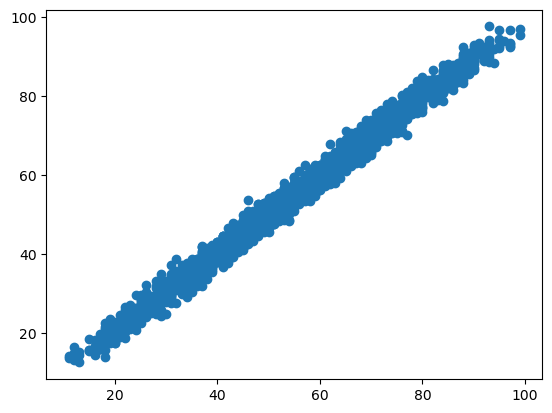

In [104]:
plt.scatter(x=y_test,y=y_predict_lr)

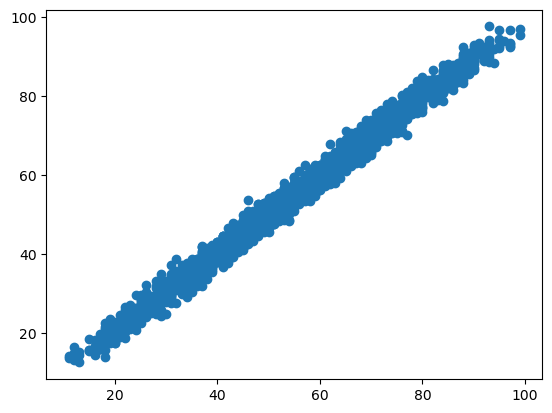

In [105]:
plt.scatter(y_test, y_predict_lr)

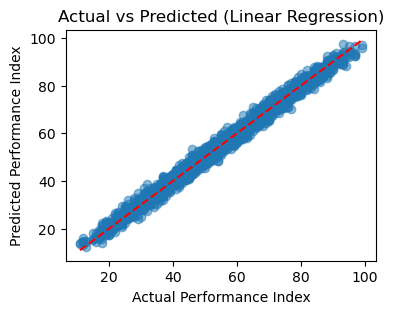

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.scatter(y_test, y_predict_lr, alpha=0.5)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted (Linear Regression)")
# Perfect prediction ki line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

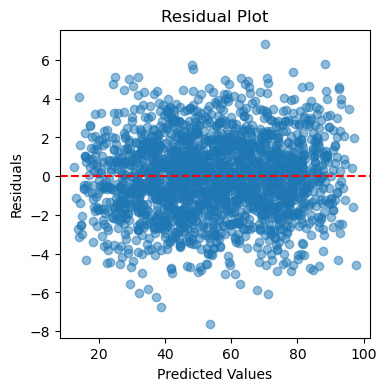

In [61]:
residuals = y_test - y_predict_lr
plt.figure(figsize=(4,4))
plt.scatter(y_predict_lr, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()